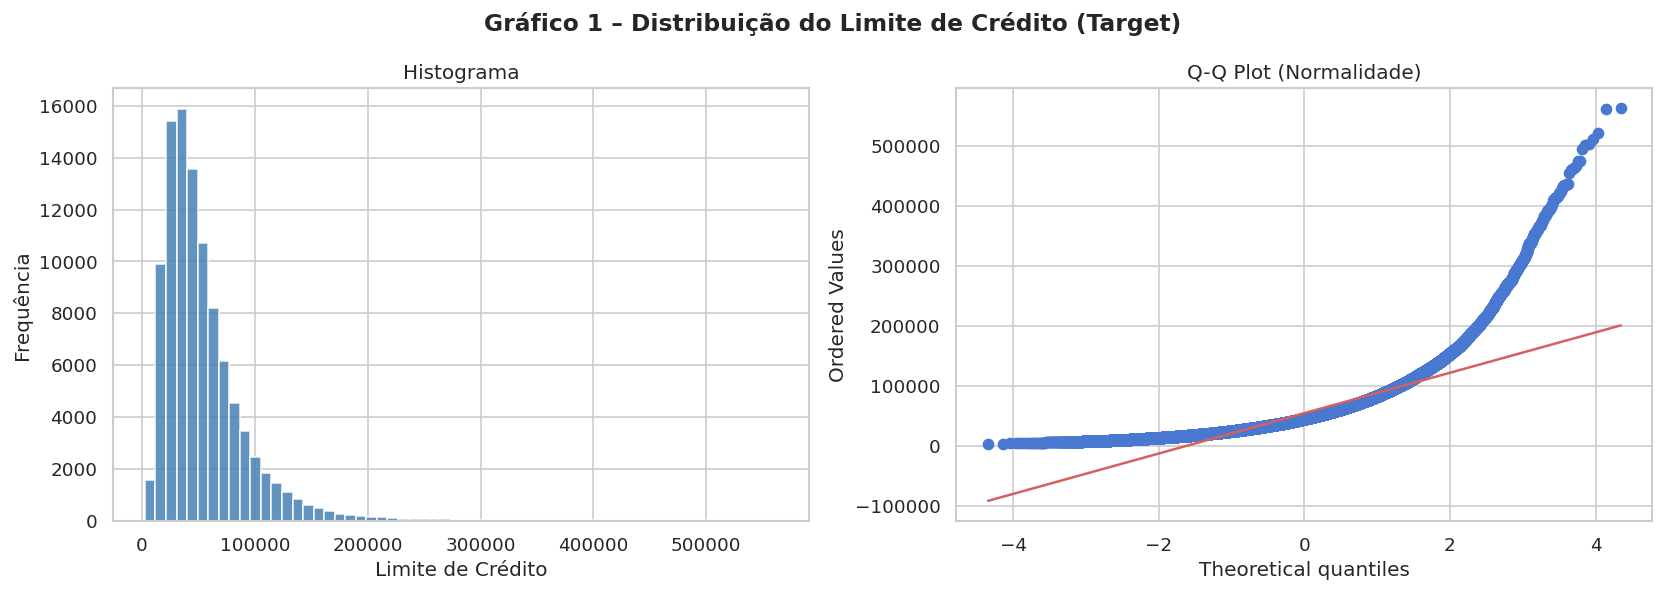

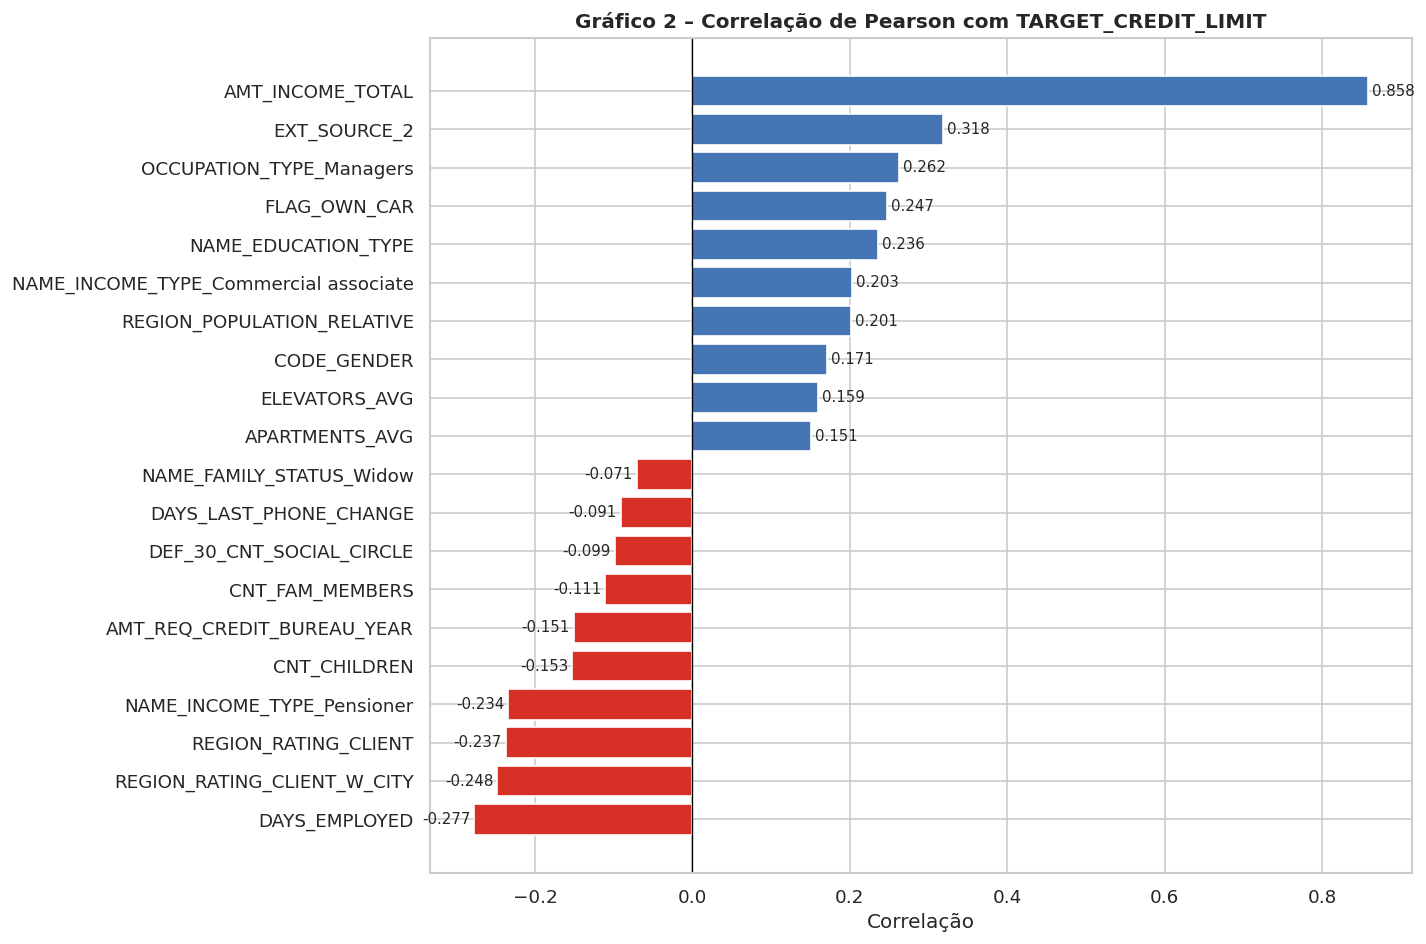

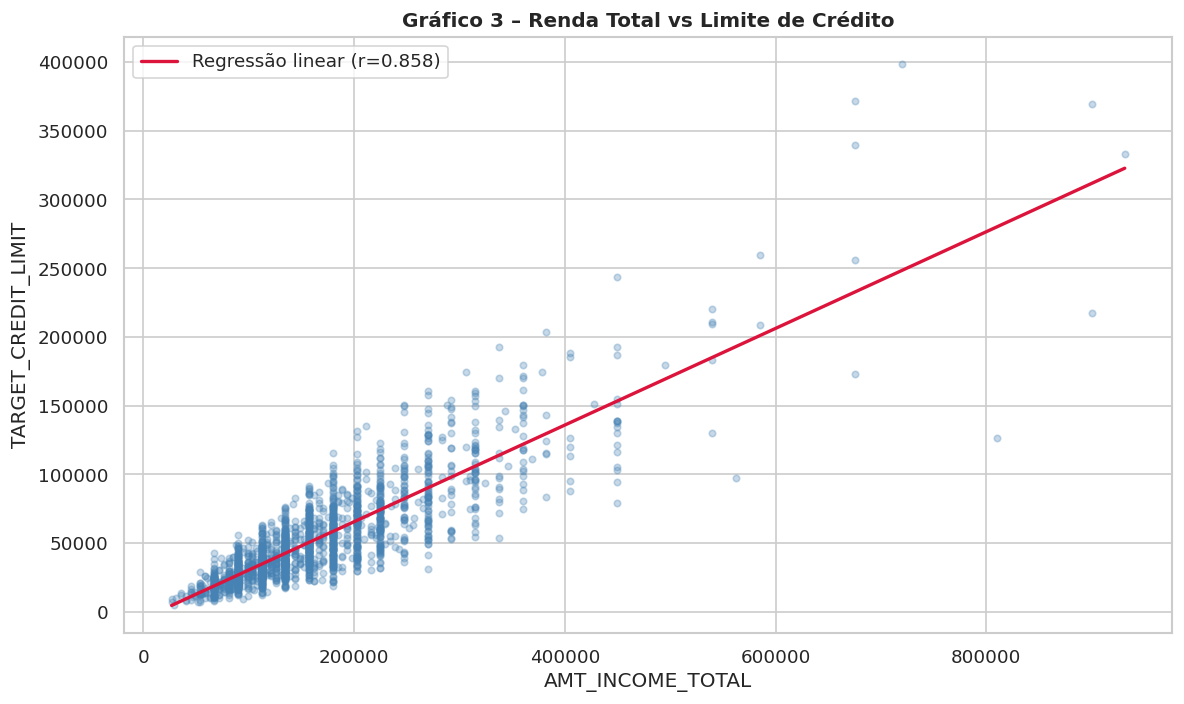

/tmp/ipykernel_8908/2359858694.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['INCOME_BIN'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=5,


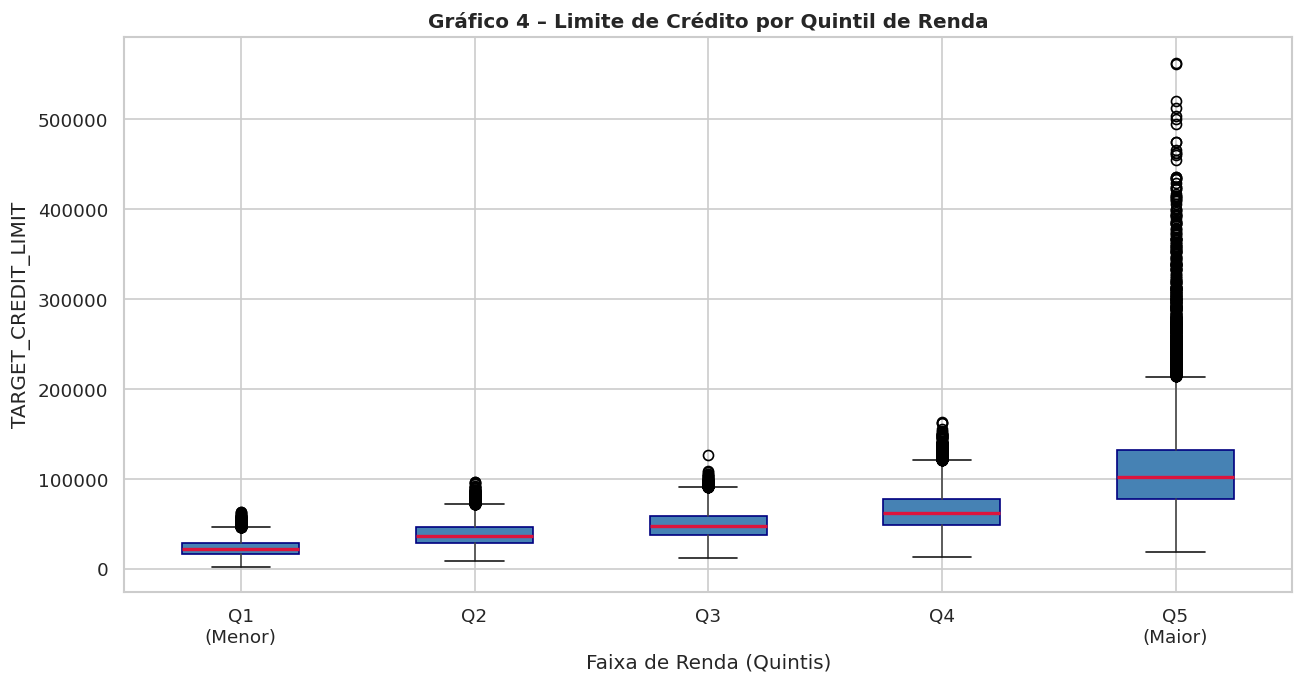

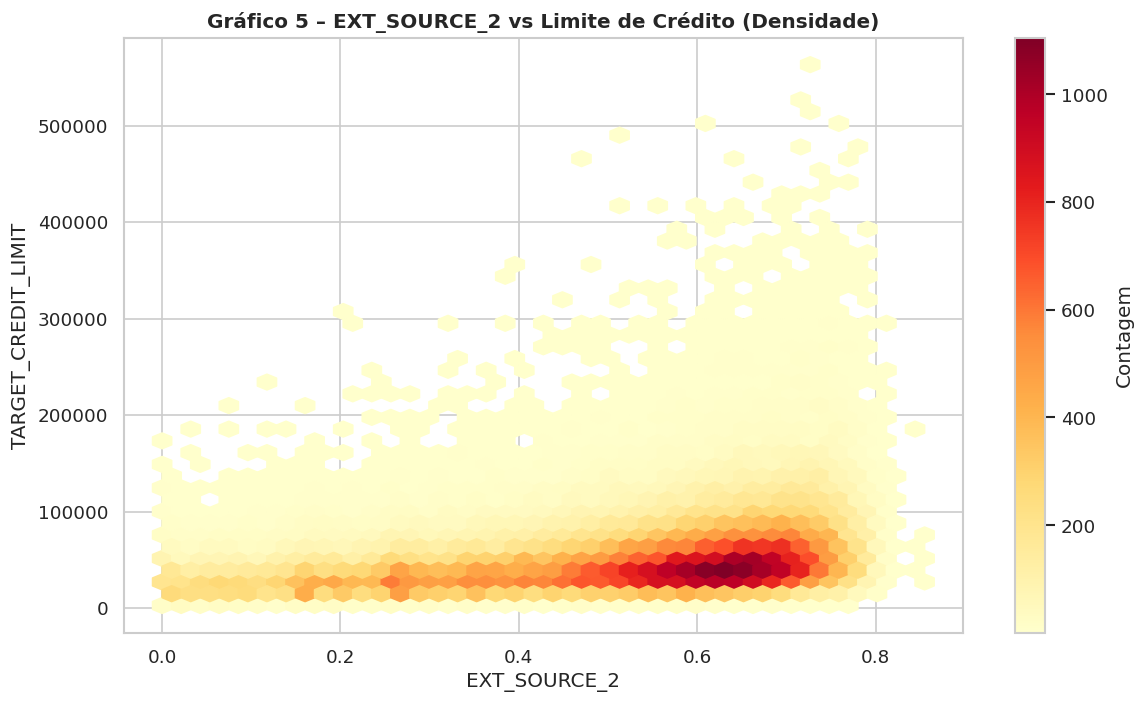

/tmp/ipykernel_8908/2359858694.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['GENDER_LABEL'] = df['CODE_GENDER'].map(gender_map)
/tmp/ipykernel_8908/2359858694.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='GENDER_LABEL', y='TARGET_CREDIT_LIMIT',


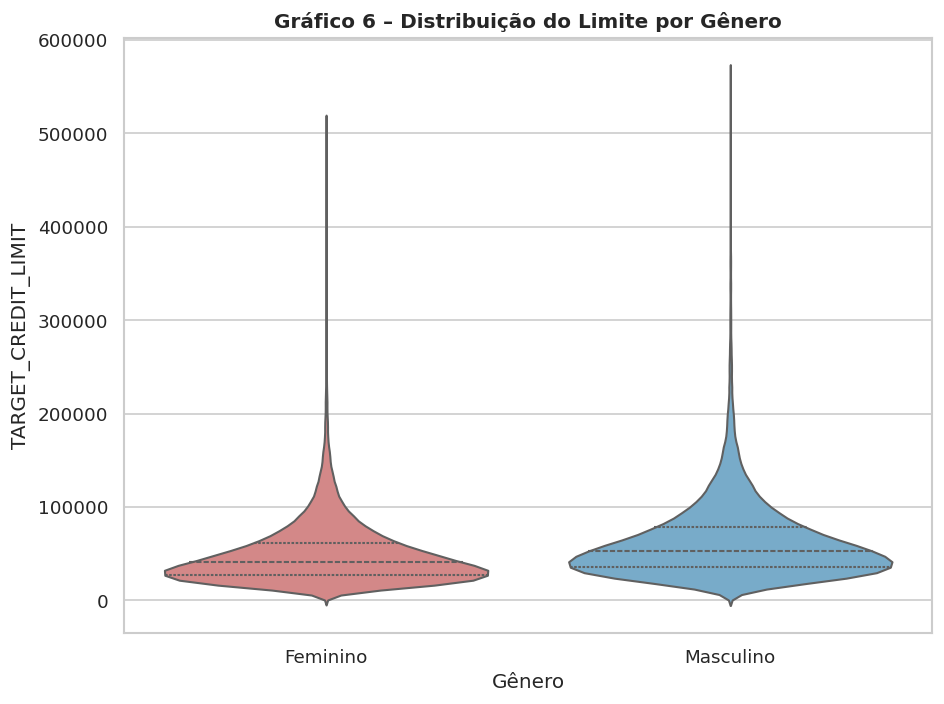

/tmp/ipykernel_8908/2359858694.py:134: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CAR_LABEL'] = df['FLAG_OWN_CAR'].map(car_map)
/tmp/ipykernel_8908/2359858694.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CAR_LABEL', y='TARGET_CREDIT_LIMIT',


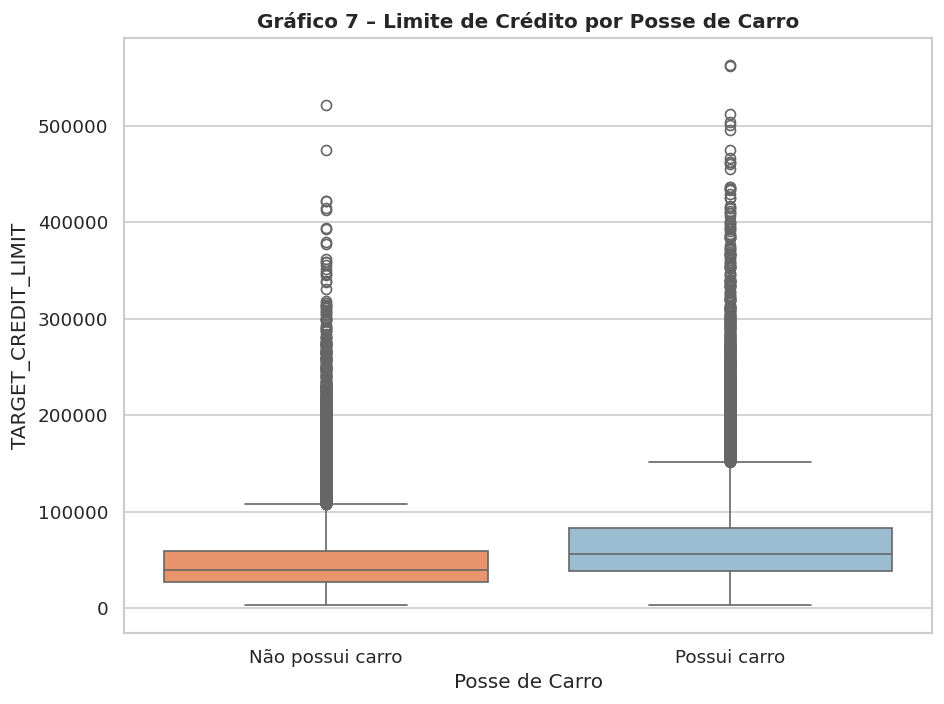

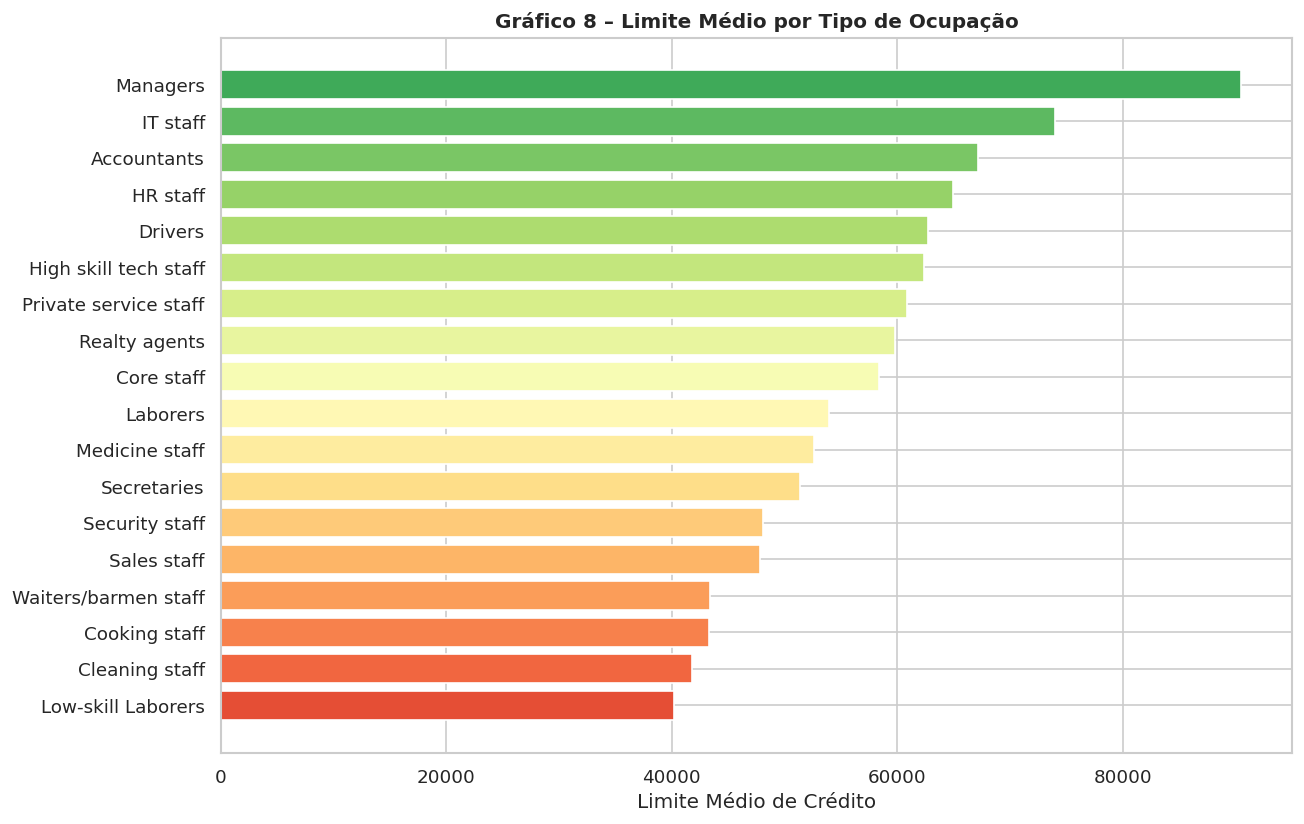

/tmp/ipykernel_8908/2359858694.py:181: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(inc_series.index, rotation=30, ha='right')


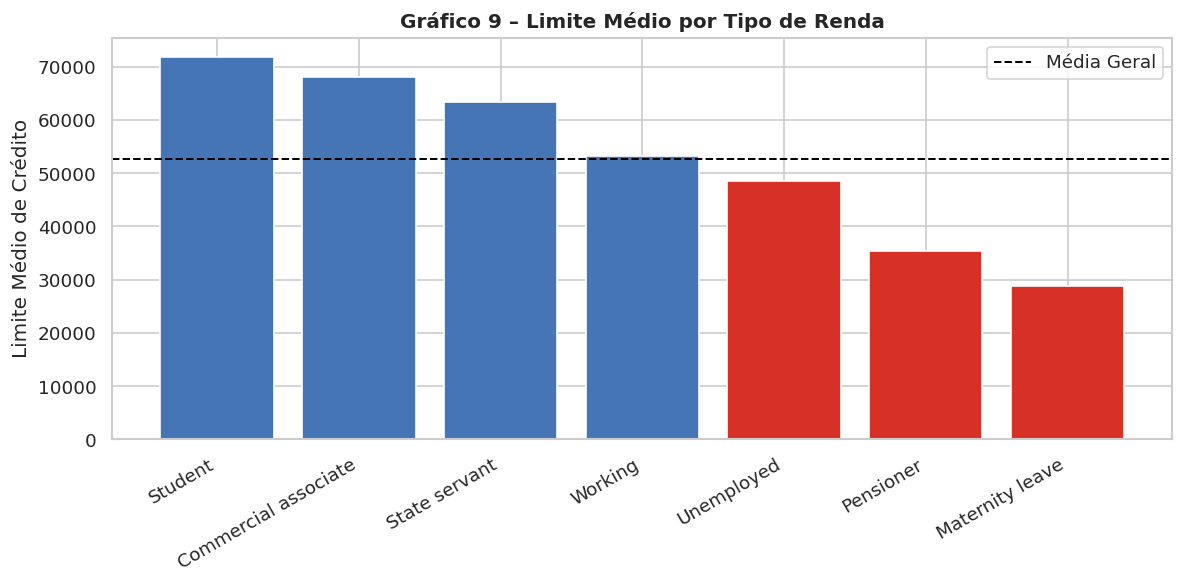

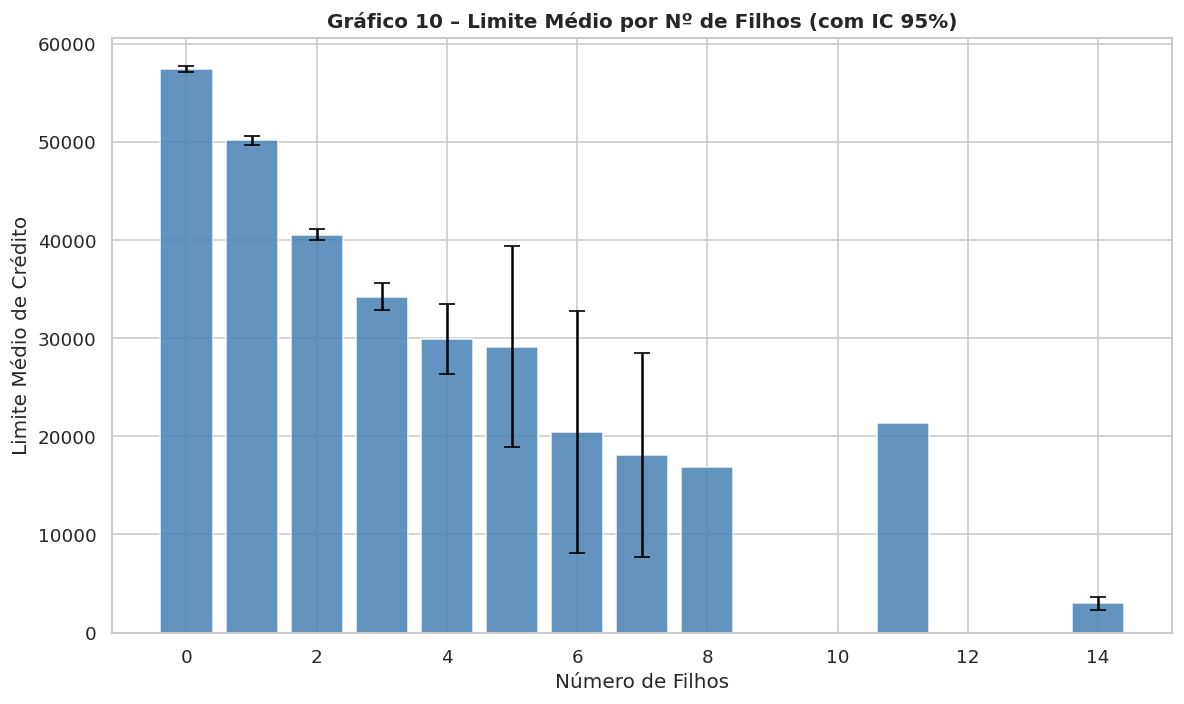

<Figure size 1200x960 with 0 Axes>

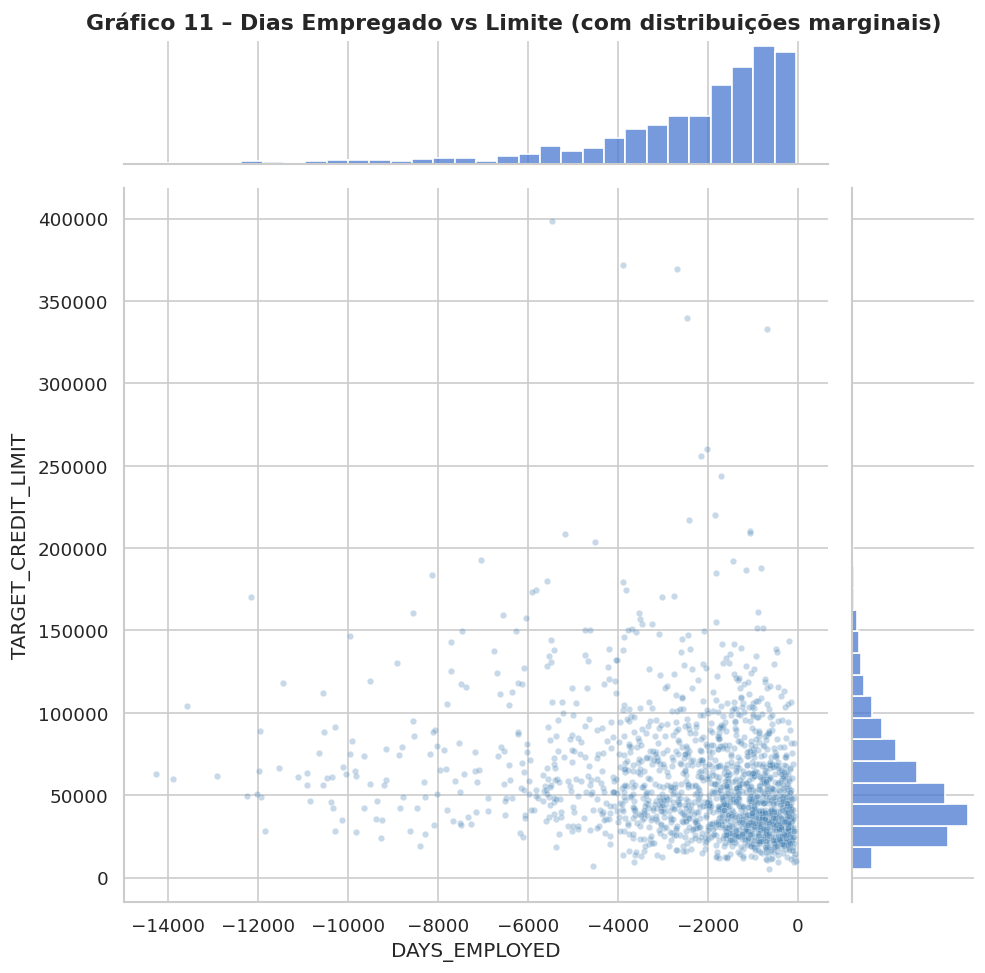

/tmp/ipykernel_8908/2359858694.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='REGION_RATING_CLIENT', y='TARGET_CREDIT_LIMIT',
/tmp/ipykernel_8908/2359858694.py:230: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='REGION_RATING_CLIENT_W_CITY', y='TARGET_CREDIT_LIMIT',


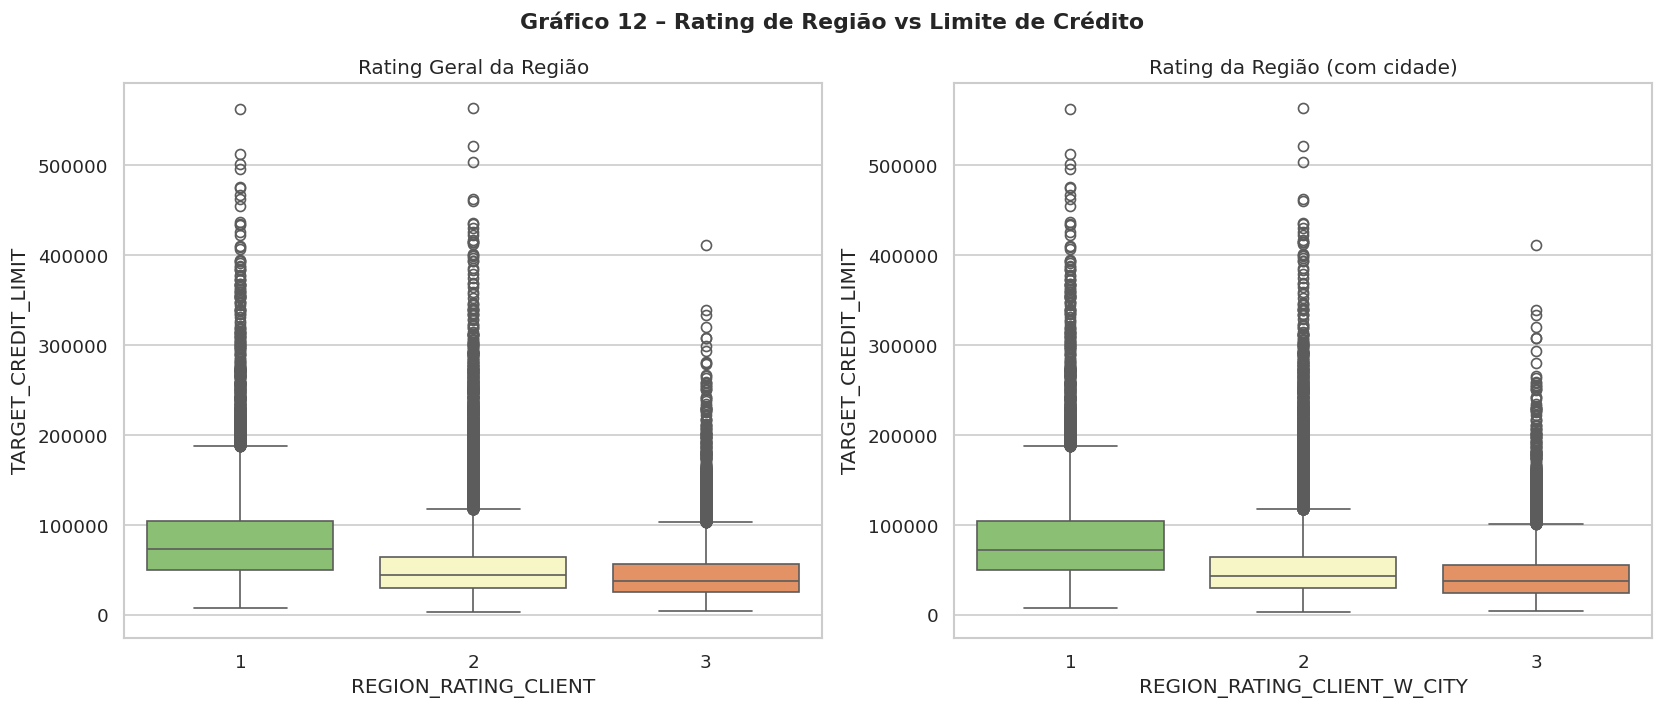

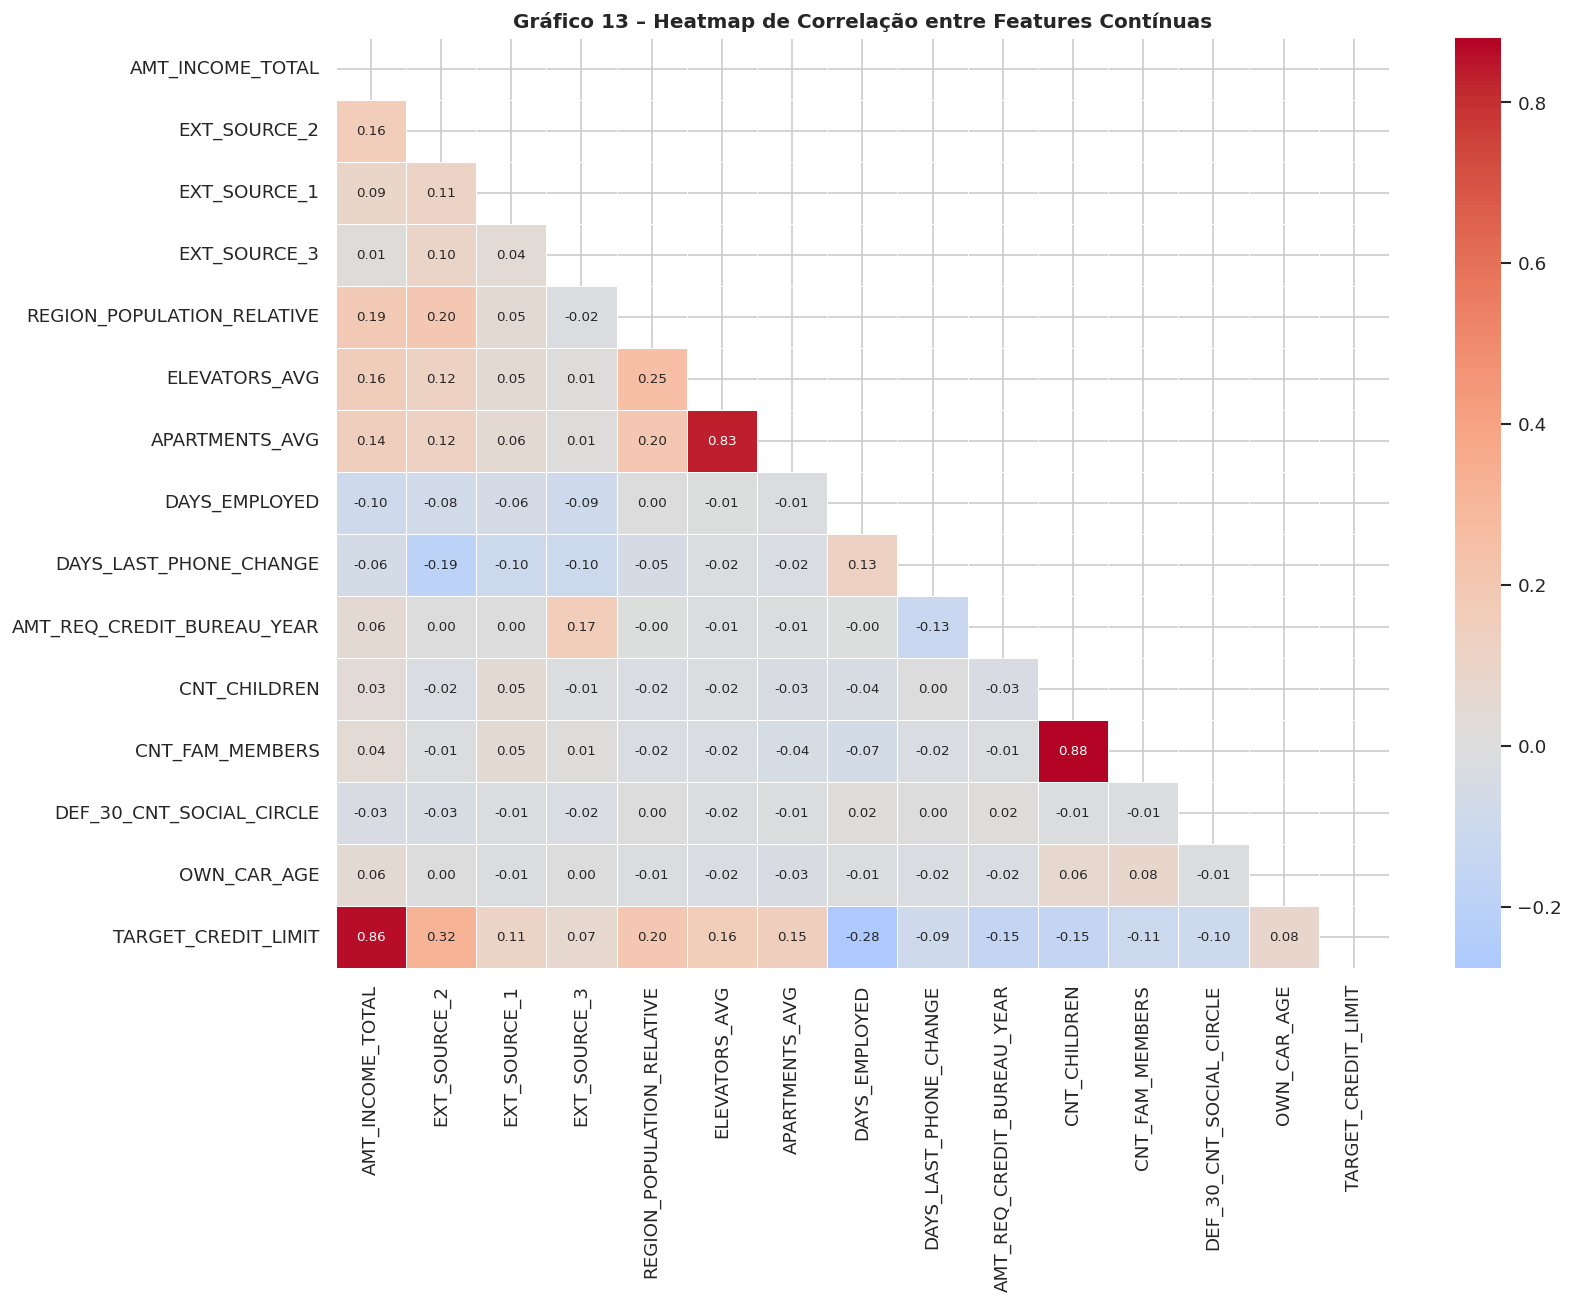

/tmp/ipykernel_8908/2359858694.py:263: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['FAMILY_STATUS'] = 'Outro'
/tmp/ipykernel_8908/2359858694.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='FAMILY_STATUS', y='TARGET_CREDIT_LIMIT',


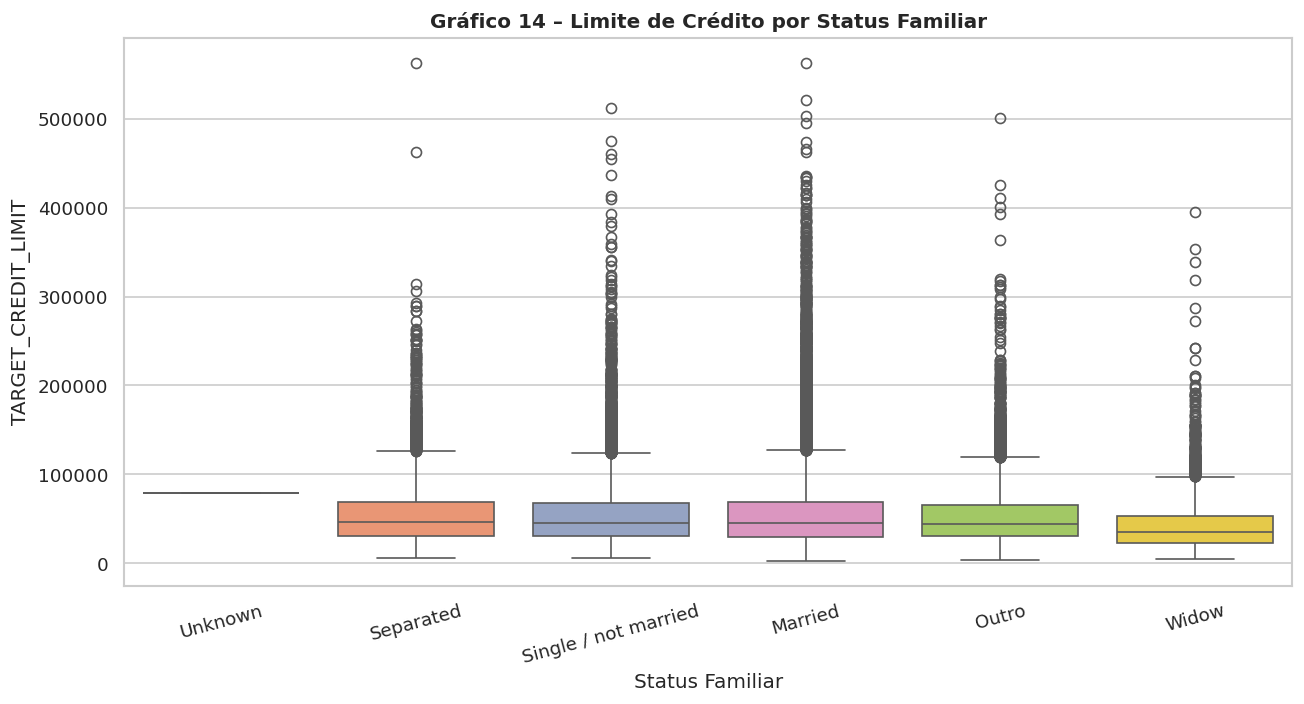

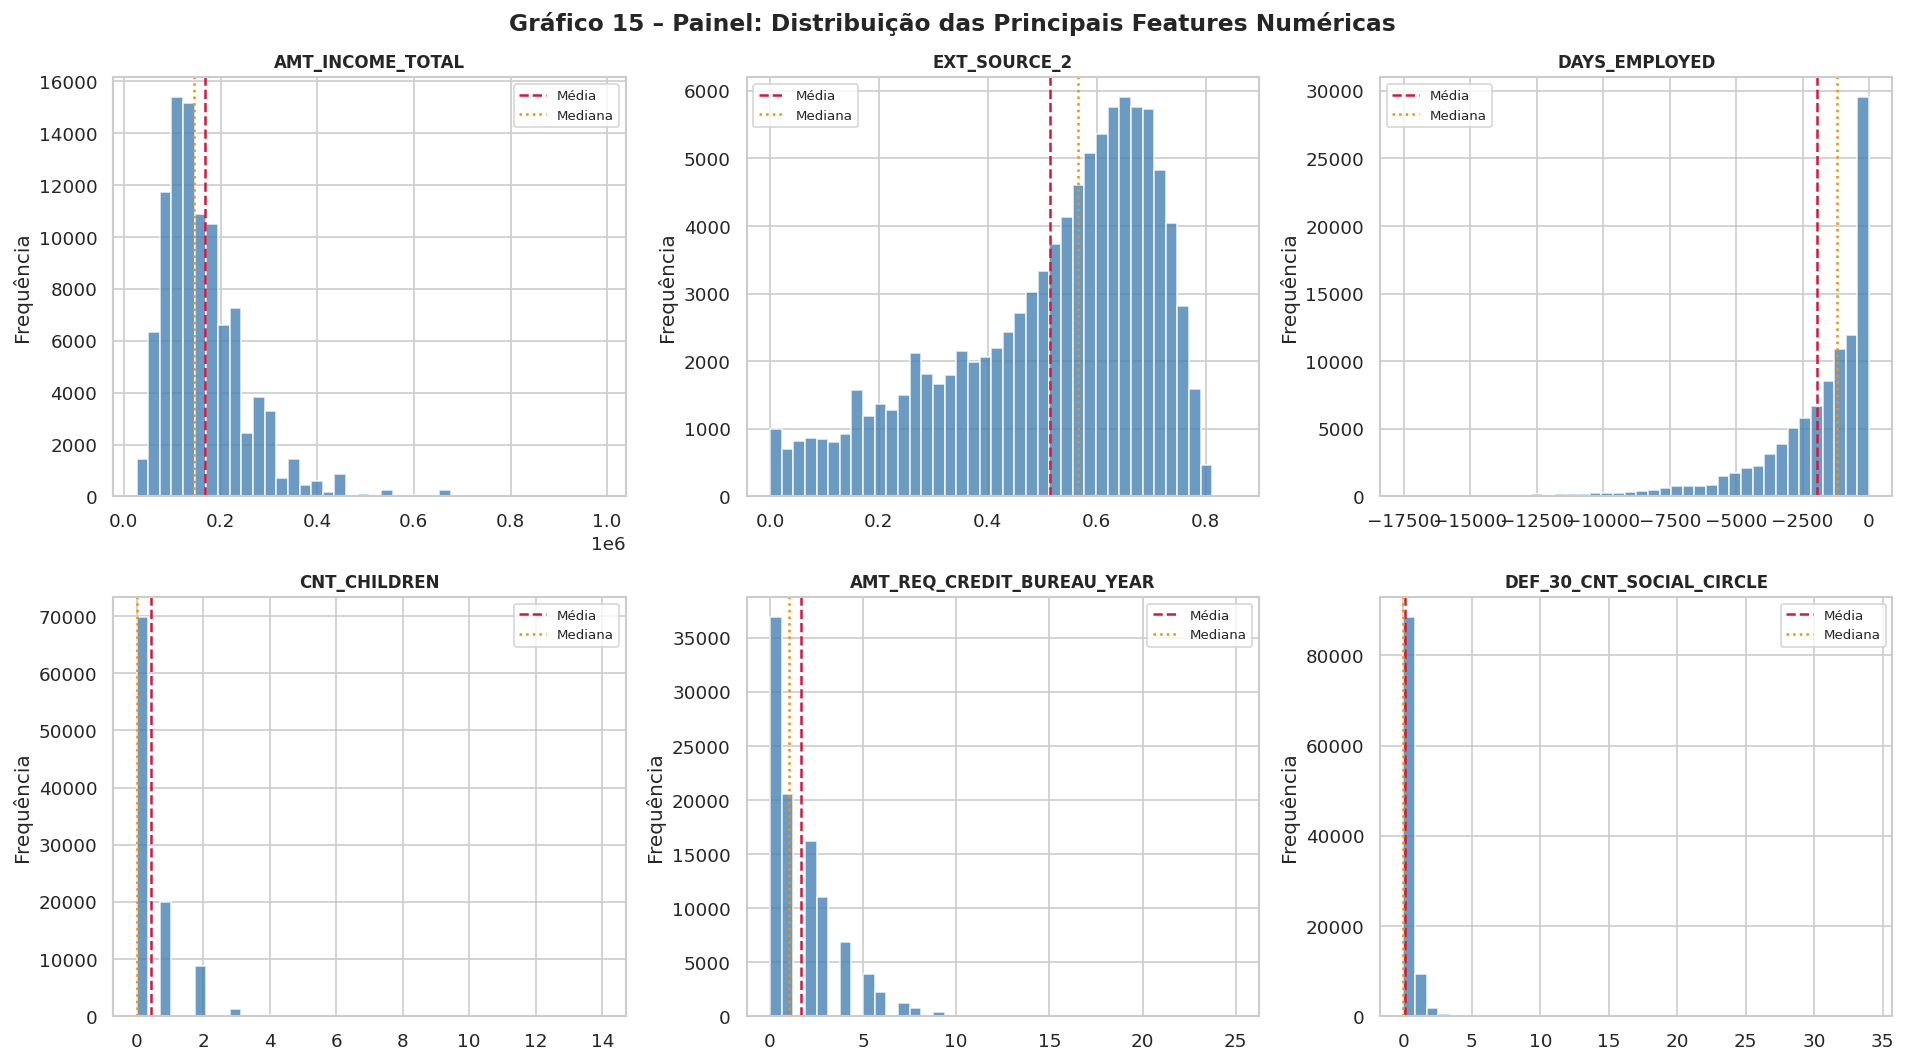

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# 1. Carrega o seu dataset já tratado
caminho_arquivo = '/home/andre/Área de trabalho/Trein 2 /Trein-2---Tato-e-Gabiru/tratamento_bases/dataset_processado_para_modelo.csv'
df = pd.read_csv(caminho_arquivo)
# Configurações globais de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# =============================================================
# Supondo que seu DataFrame já esteja carregado como: df
# =============================================================

# ── GRÁFICO 2: Correlações Absolutas — Top 20 Features ───────
top_pos = {
    'AMT_INCOME_TOTAL': 0.858, 'EXT_SOURCE_2': 0.318,
    'OCCUPATION_TYPE_Managers': 0.262, 'FLAG_OWN_CAR': 0.247,
    'NAME_EDUCATION_TYPE': 0.236, 'NAME_INCOME_TYPE_Commercial associate': 0.203,
    'REGION_POPULATION_RELATIVE': 0.201, 'CODE_GENDER': 0.171,
    'ELEVATORS_AVG': 0.159, 'APARTMENTS_AVG': 0.151,
}
top_neg = {
    'NAME_FAMILY_STATUS_Widow': -0.071, 'DAYS_LAST_PHONE_CHANGE': -0.091,
    'DEF_30_CNT_SOCIAL_CIRCLE': -0.099, 'CNT_FAM_MEMBERS': -0.111,
    'AMT_REQ_CREDIT_BUREAU_YEAR': -0.151, 'CNT_CHILDREN': -0.153,
    'NAME_INCOME_TYPE_Pensioner': -0.234, 'REGION_RATING_CLIENT': -0.237,
    'REGION_RATING_CLIENT_W_CITY': -0.248, 'DAYS_EMPLOYED': -0.277,
}
all_corr = pd.Series({**top_pos, **top_neg}).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#d73027' if v < 0 else '#4575b4' for v in all_corr.values]
bars = ax.barh(all_corr.index, all_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Gráfico 2 – Correlação de Pearson com TARGET_CREDIT_LIMIT", fontweight='bold')
ax.set_xlabel("Correlação")
for bar, val in zip(bars, all_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig("g02_correlacoes_target.png")
plt.show()


# ── GRÁFICO 3: Renda vs Limite de Crédito (Scatter + Regressão) ──
fig, ax = plt.subplots(figsize=(10, 6))
sample = df[['AMT_INCOME_TOTAL', 'TARGET_CREDIT_LIMIT']].dropna().sample(min(2000, len(df)), random_state=42)
ax.scatter(sample['AMT_INCOME_TOTAL'], sample['TARGET_CREDIT_LIMIT'],
           alpha=0.3, s=15, color='steelblue')
m, b = np.polyfit(sample['AMT_INCOME_TOTAL'], sample['TARGET_CREDIT_LIMIT'], 1)
x_line = np.linspace(sample['AMT_INCOME_TOTAL'].min(), sample['AMT_INCOME_TOTAL'].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Regressão linear (r=0.858)')
ax.set_title("Gráfico 3 – Renda Total vs Limite de Crédito", fontweight='bold')
ax.set_xlabel("AMT_INCOME_TOTAL")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
ax.legend()
plt.tight_layout()
plt.savefig("g03_scatter_renda_limite.png")
plt.show()


# ── GRÁFICO 4: Limite por Faixa de Renda (Boxplot) ───────────
df['INCOME_BIN'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=5,
                            labels=['Q1\n(Menor)', 'Q2', 'Q3', 'Q4', 'Q5\n(Maior)'])

fig, ax = plt.subplots(figsize=(11, 6))
df.boxplot(column='TARGET_CREDIT_LIMIT', by='INCOME_BIN', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_title("Gráfico 4 – Limite de Crédito por Quintil de Renda", fontweight='bold')
ax.set_xlabel("Faixa de Renda (Quintis)")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
plt.suptitle("")
plt.tight_layout()
plt.savefig("g04_boxplot_renda_quintil.png")
plt.show()


# ── GRÁFICO 5: EXT_SOURCE_2 vs Limite (Hexbin) ───────────────
fig, ax = plt.subplots(figsize=(10, 6))
sample2 = df[['EXT_SOURCE_2', 'TARGET_CREDIT_LIMIT']].dropna()
hb = ax.hexbin(sample2['EXT_SOURCE_2'], sample2['TARGET_CREDIT_LIMIT'],
               gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Contagem')
ax.set_title("Gráfico 5 – EXT_SOURCE_2 vs Limite de Crédito (Densidade)", fontweight='bold')
ax.set_xlabel("EXT_SOURCE_2")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
plt.tight_layout()
plt.savefig("g05_hexbin_ext_source2.png")
plt.show()


# ── GRÁFICO 6: Limite por Gênero (Violin) ────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
gender_map = {0: 'Feminino', 1: 'Masculino'}
df['GENDER_LABEL'] = df['CODE_GENDER'].map(gender_map)
sns.violinplot(data=df, x='GENDER_LABEL', y='TARGET_CREDIT_LIMIT',
               palette=['#e07b7b', '#6baed6'], inner='quartile', ax=ax)
ax.set_title("Gráfico 6 – Distribuição do Limite por Gênero", fontweight='bold')
ax.set_xlabel("Gênero")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
plt.tight_layout()
plt.savefig("g06_violin_genero.png")
plt.show()


# ── GRÁFICO 7: Limite por Posse de Carro (Boxplot comparativo) ──
fig, ax = plt.subplots(figsize=(8, 6))
car_map = {0: 'Não possui carro', 1: 'Possui carro'}
df['CAR_LABEL'] = df['FLAG_OWN_CAR'].map(car_map)
sns.boxplot(data=df,e x='CAR_LABEL', y='TARGET_CREDIT_LIMIT',
            palette=['#fc8d59', '#91bfdb'], ax=ax)
ax.set_title("Gráfico 7 – Limite de Crédito por Posse de Carro", fontweight='bold')
ax.set_xlabel("Posse de Carro")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
plt.tight_layout()
plt.savefig("g07_boxplot_carro.png")
plt.show()


# ── GRÁFICO 8: Limite Médio por Tipo de Ocupação ─────────────
occ_cols = [c for c in df.columns if c.startswith('OCCUPATION_TYPE_')]
occ_means = {}
for col in occ_cols:
    label = col.replace('OCCUPATION_TYPE_', '')
    mean_val = df.loc[df[col] == True, 'TARGET_CREDIT_LIMIT'].mean()
    occ_means[label] = mean_val

occ_series = pd.Series(occ_means).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors_occ = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(occ_series)))
ax.barh(occ_series.index, occ_series.values, color=colors_occ, edgecolor='white')
ax.set_title("Gráfico 8 – Limite Médio por Tipo de Ocupação", fontweight='bold')
ax.set_xlabel("Limite Médio de Crédito")
plt.tight_layout()
plt.savefig("g08_limite_por_ocupacao.png")
plt.show()


# ── GRÁFICO 9: Limite Médio por Tipo de Renda ────────────────
inc_cols = [c for c in df.columns if c.startswith('NAME_INCOME_TYPE_')]
inc_means = {}
for col in inc_cols:
    label = col.replace('NAME_INCOME_TYPE_', '')
    mean_val = df.loc[df[col] == True, 'TARGET_CREDIT_LIMIT'].mean()
    inc_means[label] = mean_val

inc_series = pd.Series(inc_means).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#4575b4' if v >= inc_series.mean() else '#d73027' for v in inc_series.values]
ax.bar(inc_series.index, inc_series.values, color=palette, edgecolor='white')
ax.axhline(inc_series.mean(), color='black', linestyle='--', linewidth=1.2, label='Média Geral')
ax.set_title("Gráfico 9 – Limite Médio por Tipo de Renda", fontweight='bold')
ax.set_ylabel("Limite Médio de Crédito")
ax.set_xticklabels(inc_series.index, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig("g09_limite_por_tipo_renda.png")
plt.show()


# ── GRÁFICO 10: Limite vs Número de Filhos (Barras + IC 95%) ──
fig, ax = plt.subplots(figsize=(10, 6))
children_group = df.groupby('CNT_CHILDREN')['TARGET_CREDIT_LIMIT']
means = children_group.mean()
sems  = children_group.sem() * 1.96  # IC 95%

ax.bar(means.index, means.values, color='steelblue', edgecolor='white', alpha=0.85)
ax.errorbar(means.index, means.values, yerr=sems.values,
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_title("Gráfico 10 – Limite Médio por Nº de Filhos (com IC 95%)", fontweight='bold')
ax.set_xlabel("Número de Filhos")
ax.set_ylabel("Limite Médio de Crédito")
plt.tight_layout()
plt.savefig("g10_limite_por_filhos.png")
plt.show()


# ── GRÁFICO 11: Dias Empregado vs Limite (Scatter com KDE marginal) ──
fig = plt.figure(figsize=(10, 8))
sample3 = df[['DAYS_EMPLOYED', 'TARGET_CREDIT_LIMIT']].dropna().sample(min(2000, len(df)), random_state=42)
# Filtrar valores anômalos comuns nesta feature (365243 = desempregado)
sample3 = sample3[sample3['DAYS_EMPLOYED'] < 0]

g = sns.jointplot(data=sample3, x='DAYS_EMPLOYED', y='TARGET_CREDIT_LIMIT',
                  kind='scatter', alpha=0.3, height=8,
                  marginal_kws=dict(bins=30, fill=True),
                  joint_kws=dict(s=15, color='steelblue'))
g.fig.suptitle("Gráfico 11 – Dias Empregado vs Limite (com distribuições marginais)",
               y=1.01, fontweight='bold')
plt.savefig("g11_jointplot_dias_empregado.png")
plt.show()


# ── GRÁFICO 12: Rating de Região vs Limite (Boxplot comparativo) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Gráfico 12 – Rating de Região vs Limite de Crédito", fontweight='bold')

sns.boxplot(data=df, x='REGION_RATING_CLIENT', y='TARGET_CREDIT_LIMIT',
            palette='RdYlGn_r', ax=axes[0])
axes[0].set_title("Rating Geral da Região")
axes[0].set_xlabel("REGION_RATING_CLIENT")

sns.boxplot(data=df, x='REGION_RATING_CLIENT_W_CITY', y='TARGET_CREDIT_LIMIT',
            palette='RdYlGn_r', ax=axes[1])
axes[1].set_title("Rating da Região (com cidade)")
axes[1].set_xlabel("REGION_RATING_CLIENT_W_CITY")

plt.tight_layout()
plt.savefig("g12_boxplot_rating_regiao.png")
plt.show()


# ── GRÁFICO 13: Heatmap de Correlação — Features Contínuas Top ──
cont_features = [
    'AMT_INCOME_TOTAL', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'EXT_SOURCE_3',
    'REGION_POPULATION_RELATIVE', 'ELEVATORS_AVG', 'APARTMENTS_AVG',
    'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OWN_CAR_AGE', 'TARGET_CREDIT_LIMIT'
]
corr_matrix = df[cont_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title("Gráfico 13 – Heatmap de Correlação entre Features Contínuas", fontweight='bold')
plt.tight_layout()
plt.savefig("g13_heatmap_correlacao.png")
plt.show()


# ── GRÁFICO 14: Limite por Status Familiar (Boxplot) ──────────
fam_cols = [c for c in df.columns if c.startswith('NAME_FAMILY_STATUS_')]
df['FAMILY_STATUS'] = 'Outro'
for col in fam_cols:
    label = col.replace('NAME_FAMILY_STATUS_', '')
    df.loc[df[col] == True, 'FAMILY_STATUS'] = label

order = (df.groupby('FAMILY_STATUS')['TARGET_CREDIT_LIMIT']
           .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df, x='FAMILY_STATUS', y='TARGET_CREDIT_LIMIT',
            order=order, palette='Set2', ax=ax)
ax.set_title("Gráfico 14 – Limite de Crédito por Status Familiar", fontweight='bold')
ax.set_xlabel("Status Familiar")
ax.set_ylabel("TARGET_CREDIT_LIMIT")
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig("g14_boxplot_status_familiar.png")
plt.show()


